# Partielle Differentialgleichungen

### Dirichlet - Randbedingungen
**Beispiel** Die eindimensionale Wärmeleitungsgleichung für die Temperatur $u = u(t, x)$ mit **Dirichlet Randbegingungen** lautet

\begin{align*}
    u(t, x)_{.t} &=& a \cdot u_{.xx}, \,\, (0 \leq x \leq L) \\ 
    u(t, x = 0) &=& u_0 \\
    u(t, x = L) &=& u_J \\
    u(t = 0, x) &=& \phi(x) \qquad \textrm{Anfangsbedingung}
\end{align*}

Wen man dies **räumlich** diskretisiert, mit **räumlicher Schrittweite** $h$ 

$$
    u(t, x_j) = u_j(t), \qquad (0 \leq j \leq J)
$$

so erhält man ein **System** für die Funktionen $\vec{u}(t) = u_j(t)$

\begin{align*}
    \frac{d}{dt} \, u_j(t) &=& \frac{a}{h^2} \cdot \left( u_{j+1}(t) - 2 u_j(t) + 2_{j-1}(t) \right), \qquad (0 < j < J)  \\[.5em]
    \vec{u}(t = 0) &=& \phi(x_i) \qquad \textrm{Anfangsbedingung} \\[.5em]
    u_0(t) &=& \ldots \qquad \textrm{Randbedingung links} \\
    u_J(t) &=& \ldots \qquad \textrm{Randbedingung rechts}  
\end{align*}

Zur Lösung diskretisiert man auch in Zeitrichtung mit einer **zeitlichen Schrittweite** $\tau$ und verwendet eines der Verfahren aus dem Abschnitt gewöhnliche Differentialgleichungen.



### FTCS: Forward Time, Centered Space
Das FTCS-Schema löst das System von gDgl mit der **expliziten Eulermethode** ("forward time") und zentralen Differenzenquotienten in $x$ ("Centered Space")

$$
    \vec{u}(t + \tau) = \vec{u}(t) + \tau \, \frac{d}{dt} \, \vec{u}(t) \quad \implies \quad
    u_{n+1, j} = u_{n, j} + \tau \, \frac{a}{h^2} \, (u_{n,j+1} - 2 u_{n, j} + u_{n, j-1})
$$

Die Stabilitätsbedingung für das Eulerverfahren verlangt
$$
    \tau < \frac{h^2}{2 a}
$$

**Beispiel**
Die eindimensionale Wärmeleitungsgleichung wird mit Dirichlet Randbedingungen (also konstanten Temperaturen an den Stabenden) gelöst. 
Im **stationären Zustand**, der sich für $t \to \infty$ einstellt, wird der Temperaturverlauf linear zwischen diesen zwei Temperaturen. Die Bedingung in der pDgl ist 

$$
    u_{.t} = 0 \quad \implies \quad u_{.xx} = 0
$$

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

#%% Parameter
a = 1           # Temperaturleitfähigkeit

L = 1           # Länge des x-Intervalls
J = 20          # Anzahl Unterteilungen in x-Richtung
tEnd = .5       # Zeit

Die zeitliche Diskretisierung $\tau$ ist begrenzt durch die räumliche Diskretisierung

In [ ]:
h   = L / (J+1)           # räumliche Diskretisierung ("Ortsschritt")
tau = h**2 / a / 2 * .9  # Zeitschritt (Stabilitätsgrenze ist h**2 / a / 2)
N = int(tEnd / tau) + 1

Anfangs- und (Dirichlet)-Randbedingungen

In [ ]:

phi = lambda x : (x-L/2)**3 # willkürliche Anfangsbedingung
u0  = lambda t : phi(0)     # Randbedingungen konstant und konsistent mit Anfangsbedingung
uJ  = lambda t : phi(L)

FTCS-Schema, Es wird hier immer nur ein Zwischenergebnis des Zeitverlaufs gespeichert, um das nächste zu berechnen, also
$$
    u \in \mathbb{R}^{2, J+1}
$$

wobei die erste ($j = 0$) und letzte ($j = J$) Spalte von $u$ durch die Randbedingungen vorgegeben sind.

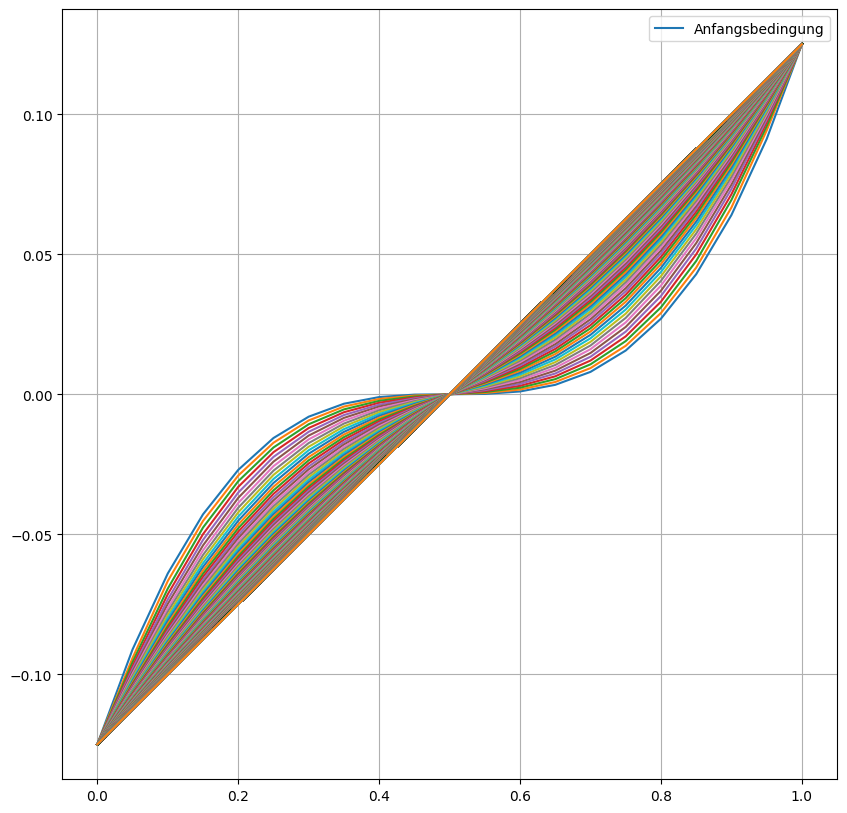

In [ ]:

u = np.zeros( (2, J+1) ) # (u_0, ..., u_J), also J+1 Punkte. 
X = np.linspace(0, L,    J+1)
T = np.linspace(0, tEnd, N)

u[0] = phi(X)       # Anfangsbedingung
u[:,0]  = u0(T)     # Randbedingung links
u[:,-1] = uJ(T)     # Randbedingung rechts

#%% FTCS
plt.figure(1,[10,10])
plt.plot(X, u[0], label = "Anfangsbedingung")
plt.grid(True)
s = tau * a / h**2
for n in range(N):
    u[1, 1:J] = s * (u[0, 2:J+1] + u[0, :J-1]) + (1 - 2 * s) * u[0, 1:J] # u[t, 0] und u[t,J] sind Randbedingungen
    u[0] = u[1]
    if (n+1) % 1 == 0:
        plt.plot(X, u[0])

plt.legend()

### Das Crank-Nicholson-Schema

Das **Crank-Nicholson-Schema** löst das System von gDgl mit der **impliziten Trapezmethode**

$$
    u_{n+1,j} = u_{n, j} + \frac{\tau}{2} \, \frac{a}{h^2} \, (u_{n, j+1} - 2 u_{n,j} + u_{n, j-1} + {\color{blue} u_{n+1, j+1} - 2 u_{n+1,j} + u_{n+1, j-1}})
$$

Dies ergibt ein tridiagonales, lineares Gleichungssystem für die gesuchten $u_{n+1,j}$

In [ ]:
from scipy.linalg import solve_banded

#%% Parameter
a = 1           # Temperaturleitfähigkeit

L = 1           # Länge des x-Intervalls
J = 50         # Anzahl Unterteilungen in x-Richtung
tEnd = .5       # Zeit

Die zeitliche Schrittweite $\tau$ kann hier viel grösser gewählt werden

In [ ]:
h   = L / (J+1)           # räumliche Diskretisierung ("Ortsschritt")
tau = h**2 / a / 2 * 100  # Zeitschritt
N = int(tEnd / tau) + 1

In [ ]:
#%% Anfangs- und (Dirichlet)-Randbedingungen
phi = lambda x : (x-L/2)**3 # willkürliche Anfangsbedingung
u0  = lambda t : phi(0)      # Randbedingungen konstant und konsistent mit Anfangsbedingung
uJ  = lambda t : phi(L) 

u = np.zeros( (N, J+1) ) # (u_0, ..., u_J), also J+1 Punkte. Es wird immer nur ein Zwischenergebnis gespeichert
X = np.linspace(0, L,    J+1)
T = np.linspace(0, tEnd, N)

u[0] = phi(X)       # Anfangsbedingung
u[:,0]  = u0(T)     # Randbedingung links
u[:,-1] = uJ(T)     # Randbedingung rechts

Die Matrix des LGS ist tridiagonal und konstant (muss also nur einmal aufgebaut werden). Das LGS wird hier mit solve_banded aus scipy gelöst.

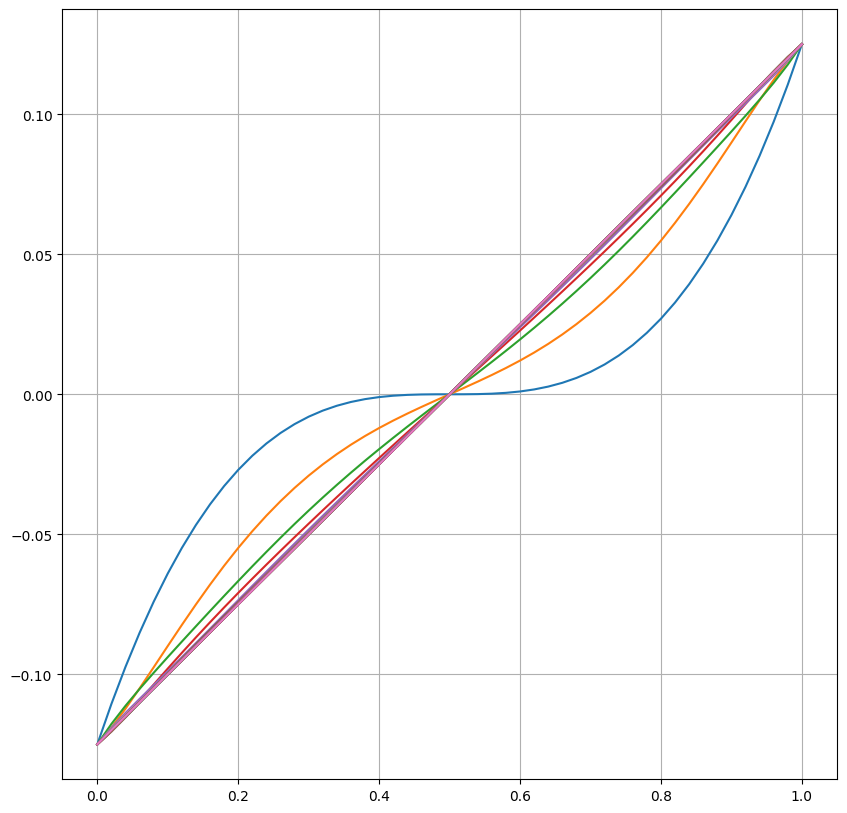

In [ ]:
#%% Crank-Nicolson
alpha = a / (2 * h**2)
beta  = 1/tau + a / h**2
gamma = 1/tau - a / h**2

ab = np.array([-alpha * np.ones(J-1), beta * np.ones(J-1), -alpha * np.ones(J-1)])

plt.figure(1,[10,10])
plt.plot(X, u[0], label = "Anfangsbedingung")
plt.grid(True)
s = tau * a / h**2

for n in range(N-1):
    b = np.array(alpha * (u[n,:-2] + u[n,2:]) + gamma * u[n,1:-1])
    b[0]  += alpha * u0(T[n+1])
    b[-1] += alpha * uJ(T[n+1])
    
    u[n+1,1:-1] = solve_banded( (1, 1), ab, b)
    if (n+1) % 1 == 0:
        plt.plot(X, u[n+1])
plt.show()

### Neumann-Randbedingungen
Hier sind anstelle der Werte 
$$
    u(t, x = 0) \quad \textrm{und} \quad u(t, x = L)
$$

die Steigungen

$$
    u_{.x}(t, x = 0) = \ell(t) \quad \textrm{und} \quad u_{.x}(t, x = L) = r(t)
$$

vorgegeben. Damit lässt sich ein Temperaturaustausch mit der Umgebung modellieren (der in unserem Modell nur an den Stabenden stattfindet). Die Aufgabe lautet damit

\begin{align*}
    u(t, x)_{.t} &=& a \cdot u_{.xx}, \,\, (0 \leq x \leq L) \\ 
    u_{.x}(t, x = 0) &=& \ell(t) \\
    u_{.x}(t, x = L) &=& r(t) \\
    u(t = 0, x) &=& \phi(x) \qquad \textrm{Anfangsbedingung}
\end{align*}

um trotzdem zentrale Differenzenquotienten (in $x$-Richtung) verwenden zu können, werden zusätzliche "Geisterpunkte" 

$$
    u_{n, J+1}, \quad \textrm{und} \quad u_{n, -1}
$$

eingeführt, die aber nie explizit verwendet werden, sondern direkt durch die Gleichung

$$
    \frac{u_{n, 1} - u_{n, -1}}{2 h} = \ell(t_n) \quad \textrm{bzw.} \quad \frac{u_{n, J+1} - u_{n, J-1}}{2 h} = r(t_n)
$$

ersetzt werden.


### FTCS mit Neumann-Randbedingungen


In [ ]:
#%% Parameter
a = 1           # Temperaturleitfähigkeit

L = 1           # Länge des x-Intervalls
J = 20          # Anzahl Unterteilungen in x-Richtung
tEnd = .5       # Zeit
    

Die zeitliche Schrittweite ist wiederum beschränkt

In [ ]:
h   = L / (J+1)           # räumliche Diskretisierung ("Ortsschritt")
tau = h**2 / a / 2 * .9  # Zeitschritt (Stabilitätsgrenze ist h**2 / a / 2)
N = int(tEnd / tau) + 1

In [ ]:
#%% Anfangs- und (Neumann)-Randbedingungen
# phi = lambda x : x * (x < L/2) + (L-x) * (x >= L /2) # willkürliche Anfangsbedingung
# w = 1

# Anfangsbedingung
phi = lambda x : 1e0 * ( np.exp(- .1 / (1e-8+np.abs(x-L)**2)) * np.exp(- .1 / (1e-8 +np.abs(x)**2)) )

Die Randbedingungen modellieren den Temperaturaustausch an den Stabenden, z.B. bedeutet

$$
    \ell(t) = 1, \qquad r(t) = 1
$$

dass am linken Ende Wärme nach links (aus dem Stab) fliesst und rechts derselbe Wärmefluss von der Umgebung in den Stab fliesst. Es kann sich ein stationärer Zustand einstellen. 

Randbedingungen

$$
    \ell(t) = -1, \qquad r(t) = 1
$$

bedeutet, dass von beiden Enden her Wärme in den Stab fliesst, dessen Wärmeinhalt folglich erhöht wird.

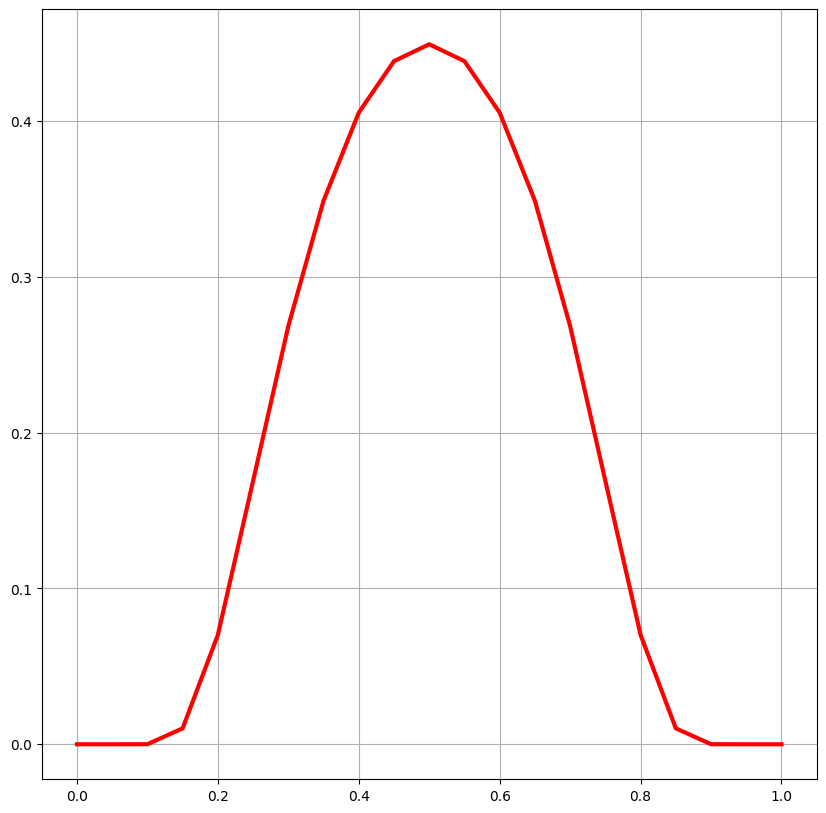

In [ ]:
# Steigungen links und rechts
l = lambda t :   0
r = lambda t :   0

u = np.zeros( (2, J+1) ) # (u_0, ..., u_J), also J+1 Punkte. Es wird immer nur ein Zwischenergebnis gespeichert
X = np.linspace(0, L,    J+1)
T = np.linspace(0, N * tau, N+1)

u[0] = phi(X)       # Anfangsbedingung

#%% FTCS
plt.figure(1,[10,10])
plt.plot(X, u[0], color = "red", linewidth = 3, label = "Anfangsbedingung")
plt.grid(True)

s = tau * a / h**2

Hier das eigentliche FTCS-Schema. Da diesmal keine Randwerte vorgegeben sind, müssen alle $u_j$, unklusive $u_0$ und $u_J$ berechnet werden.

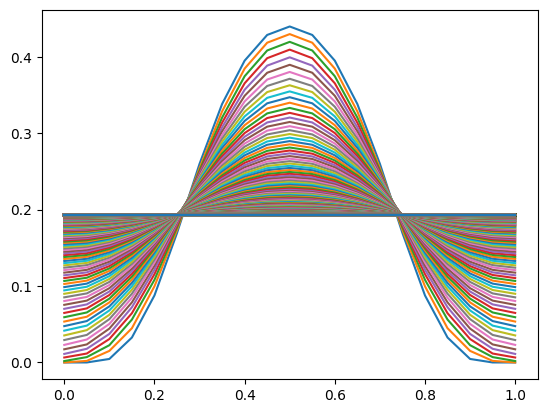

In [ ]:
for n in range(N):
    u[1, 0]   = 2 * s * ( u[0, 1] - u[0, 0] - h * l( T[n] )) + u[0,0]
    u[1, 1:J] =     s * ( u[0, 2:J+1] + u[0, :J-1]) + (1 - 2 * s) * u[0, 1:J]
    u[1, J]   = 2 * s * ( u[0, J-1] - u[0, J] + h * r( T[n] )) + u[0, J]
    
    u[0] = u[1]
    if n % 1 == 0:
        plt.plot(X, u[0])
plt.show()

### Crank-Nicholson mit Neumann-Randbedingungen

Das **Crank-Nicholson-Schema** lässt sich ebenfalls umsetzen, es müssen nur die erste und letzte Gleichung ergänzt werden:

\begin{align*}
    u_{n+1,0} &=& u_{n, 0} + \frac{\tau}{2} \, \frac{a}{h^2} \, (u_{n, 1} - 2 u_{n,0} - h \, \ell_n  + {\color{blue} u_{n+1, 1} - 2 u_{n+1,0} - h \,\ell_{n+1}}) \\[.5em]
     u_{n+1,j} &=& u_{n, j} + \frac{\tau}{2} \, \frac{a}{h^2} \, (u_{n, j+1} - 2 u_{n,j} + u_{n, j-1} + {\color{blue} u_{n+1, j+1} - 2 u_{n+1,j} + u_{n+1, j-1}})
\end{align*}

Dies ergibt ein tridiagonales, lineares Gleichungssystem für die gesuchten $u_{n+1,j}$
